In [1]:
import librosa
from scipy.signal import hilbert
import numpy as np
import matplotlib.pyplot as plt
import noisereduce as nr
import soundfile as sf
import pywt

In [2]:
audiofile = 'data/baraban-z_uk.wav'
y, sr = librosa.load(audiofile)

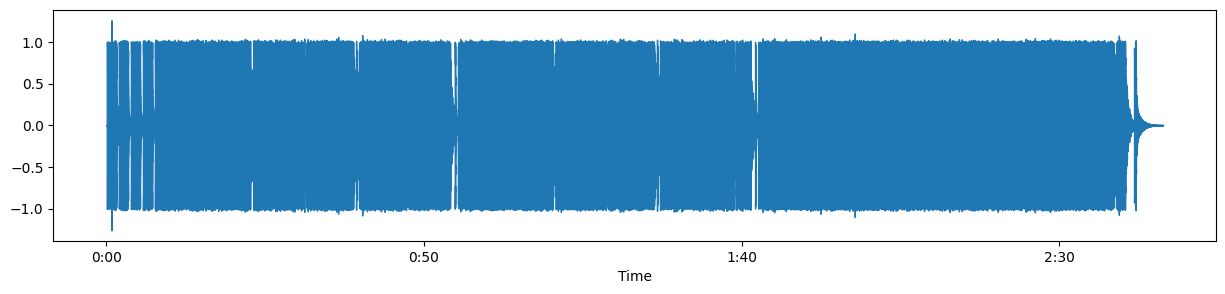

In [3]:
# Осциллограмма
plt.figure(figsize=(15, 3))
librosa.display.waveshow(y, sr=sr)
plt.show()

**статистические значения**

In [4]:
# zcr - частота, с которой сигнал меняет свой знак
zcr = librosa.feature.zero_crossing_rate(y)
zcr.mean()

np.float64(0.1743422307816425)

zcr = 0.175, из чего можно сделать вывод, что звук содержит значительное кол-во высоких частот или шума

In [5]:
# среднеквадратичная амплитуда, показывает энергию или громкость сигнала
rms = librosa.feature.rms(y=y)
dbfs = 20 * np.log10(rms.mean())
print(f'rms = {rms.mean()} = {dbfs}dB')

rms = 0.24013252556324005 = -12.39098072052002dB


rms = 0.24 (-12.4 дБ), что можно интерпретироавть как громкий, плотный и энергичный звук

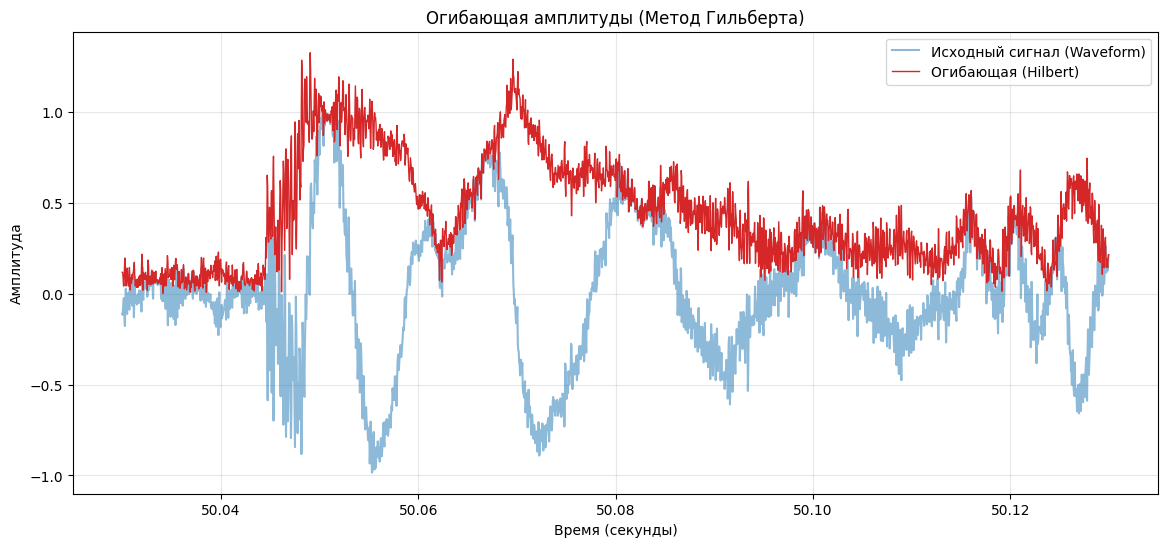

In [6]:
# огибающая амлитуды - описывает изменение амплитуды сигнала во времени, сглаживая быстрые колебания самой волны
t = np.linspace(0, len(y)/sr, len(y))

analytic_signal = hilbert(y)
amplitude_envelope = np.abs(analytic_signal)

start_time = 50.03 
end_time = 50.13
start_sample = int(start_time * sr)
end_sample = int(end_time * sr)

t_zoom = t[start_sample:end_sample]
y_zoom = y[start_sample:end_sample]
env_zoom = amplitude_envelope[start_sample:end_sample]

plt.figure(figsize=(14, 6))
plt.plot(t_zoom, y_zoom, label='Исходный сигнал (Waveform)', color='tab:blue', alpha=0.5)
plt.plot(t_zoom, env_zoom, label='Огибающая (Hilbert)', color='tab:red', linewidth=1)
plt.title('Огибающая амплитуды (Метод Гильберта)')
plt.ylabel('Амплитуда')
plt.xlabel('Время (секунды)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

In [7]:
# спектральный центроид - показывает, где сосредоточена большая часть энергии звука: в низких или высоких частотах
centroids = librosa.feature.spectral_centroid(y=y, sr=sr)
centroids.mean()


np.float64(3373.5262615979773)

centroid = 3374 - звук яркий, звонкий, шумный

Text(0.5, 1.0, 'Спектрограмма + Центроид')

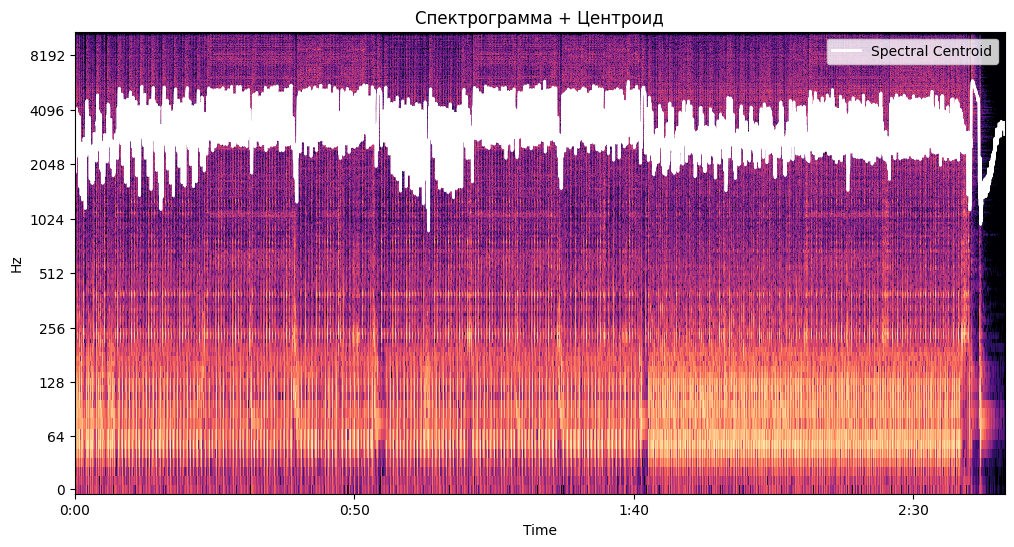

In [8]:
# визуализация спектрального центроида поверх спектрограммы
plt.figure(figsize=(12, 6))
S_dB = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='log')

times = librosa.times_like(centroids)
plt.plot(times, centroids.T, label='Spectral Centroid', color='w', linewidth=2)
plt.legend(loc='upper right')
plt.title('Спектрограмма + Центроид')

График показывает музыку, которая не сильно меняется во времени и в целом остается яркой и насыщенной

In [9]:
# спектральный спад - частота, ниже которой сосредоточен определенный процент всей энергии сигнала
rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
rolloff.mean()

np.float64(6973.988785611961)

rolloff = 6974 - нормальный, разборчивый звук, но он не содержит агрессивных высоких частот

Text(0.5, 1.0, 'Скорость изменения спектра')

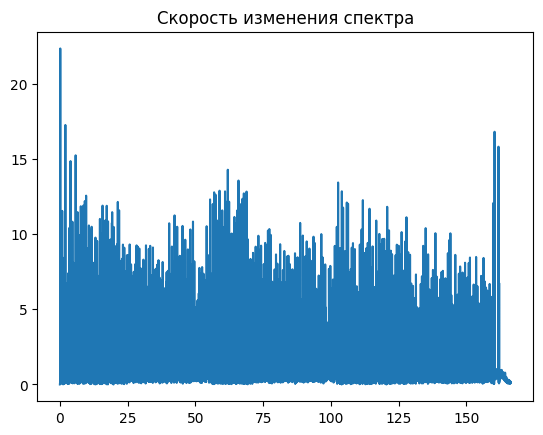

In [10]:
# спектральный поток - насколько быстро меняется спектр сигнала во времени
onset_env = librosa.onset.onset_strength(y=y, sr=sr)

times = librosa.times_like(onset_env)
plt.plot(times, onset_env, label='Spectral Flux (Onset Strength)')
plt.title('Скорость изменения спектра')

Звук имеет очень высокую, практически непрерывную ритмическую плотность с резким стартом и четко выраженной кульминацией в середине, после чего следует кратковременный спад энергии и внезапный финал без плавного затухания

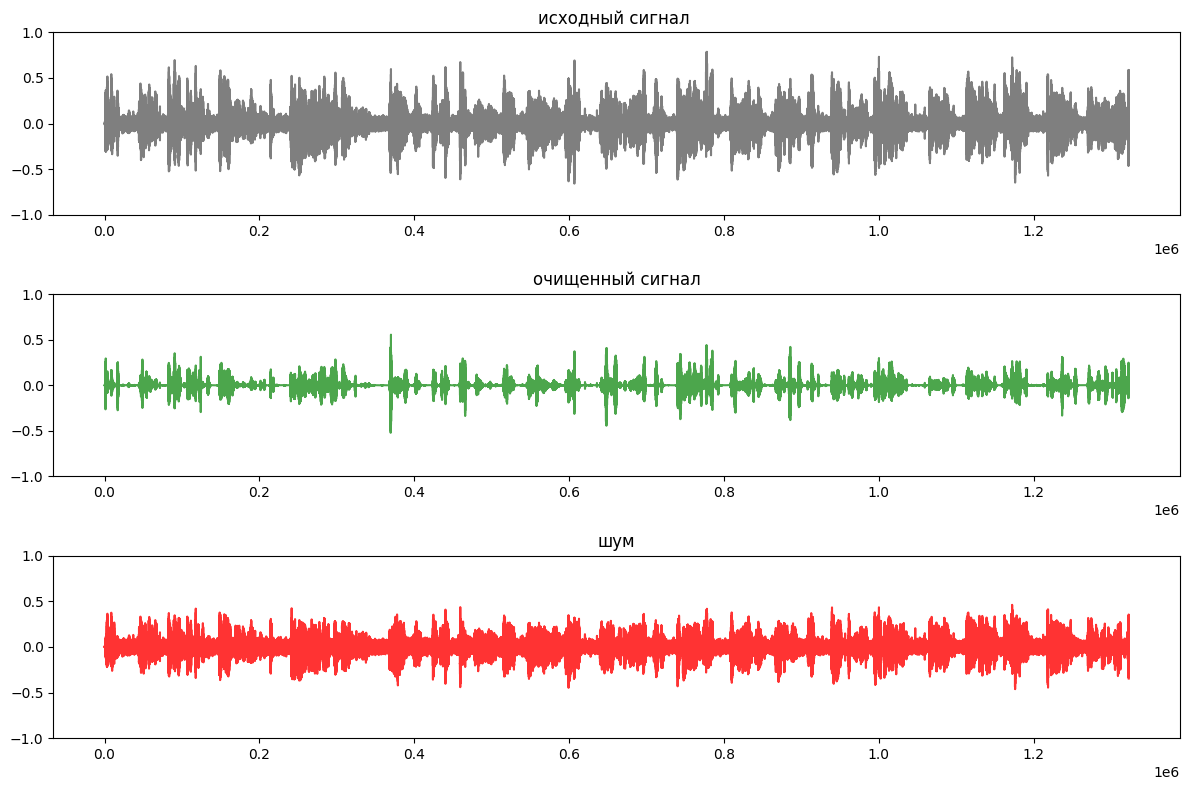

In [11]:
# нахождение шума и очистка
# используем аудио книгу с наложенным шумом города
y, sr = librosa.load('data/book_with_noise_1min.wav')

y_clean = nr.reduce_noise(y=y, sr=sr, stationary=True, prop_decrease=1.0)

noise_only = y - y_clean

plt.figure(figsize=(12, 8))

# исходный сигнал
plt.subplot(3, 1, 1)
plt.plot(y, color='black', alpha=0.5)
plt.title('исходный сигнал ')
plt.ylim([-1, 1])

# очищенный сигнал
plt.subplot(3, 1, 2)
plt.plot(y_clean, color='green', alpha=0.7)
plt.title('очищенный сигнал')
plt.ylim([-1, 1])

# шум
plt.subplot(3, 1, 3)
plt.plot(noise_only, color='red', alpha=0.8)
plt.title('шум')
plt.ylim([-1, 1])

plt.tight_layout()

# запишем в файл для прослушивания результата
sf.write('data/clear_book.wav', y_clean, sr)

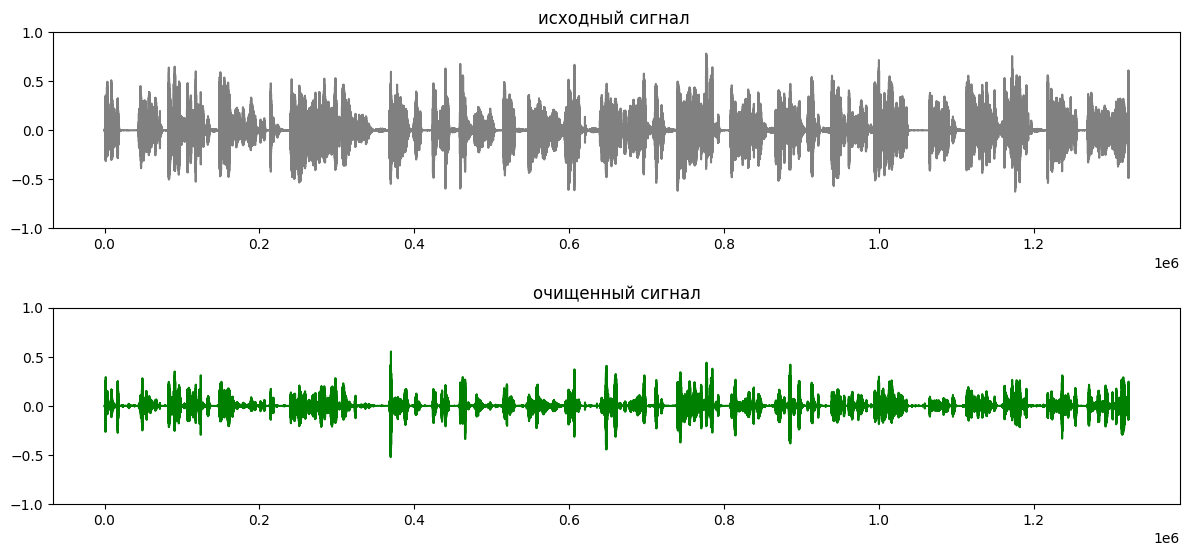

In [12]:
# сравним исходный сиигнал аудиокниги с сигналом, на который был наложен шум и очищен от него
y, sr = librosa.load('data/book_1min.wav')

plt.figure(figsize=(12, 8))

# исходный сигнал
plt.subplot(3, 1, 1)
plt.plot(y, color='gray')
plt.title('исходный сигнал ')
plt.ylim([-1, 1])

# очищенный сигнал
plt.subplot(3, 1, 2)
plt.plot(y_clean, color='green')
plt.title('очищенный сигнал')
plt.ylim([-1, 1])

plt.tight_layout()

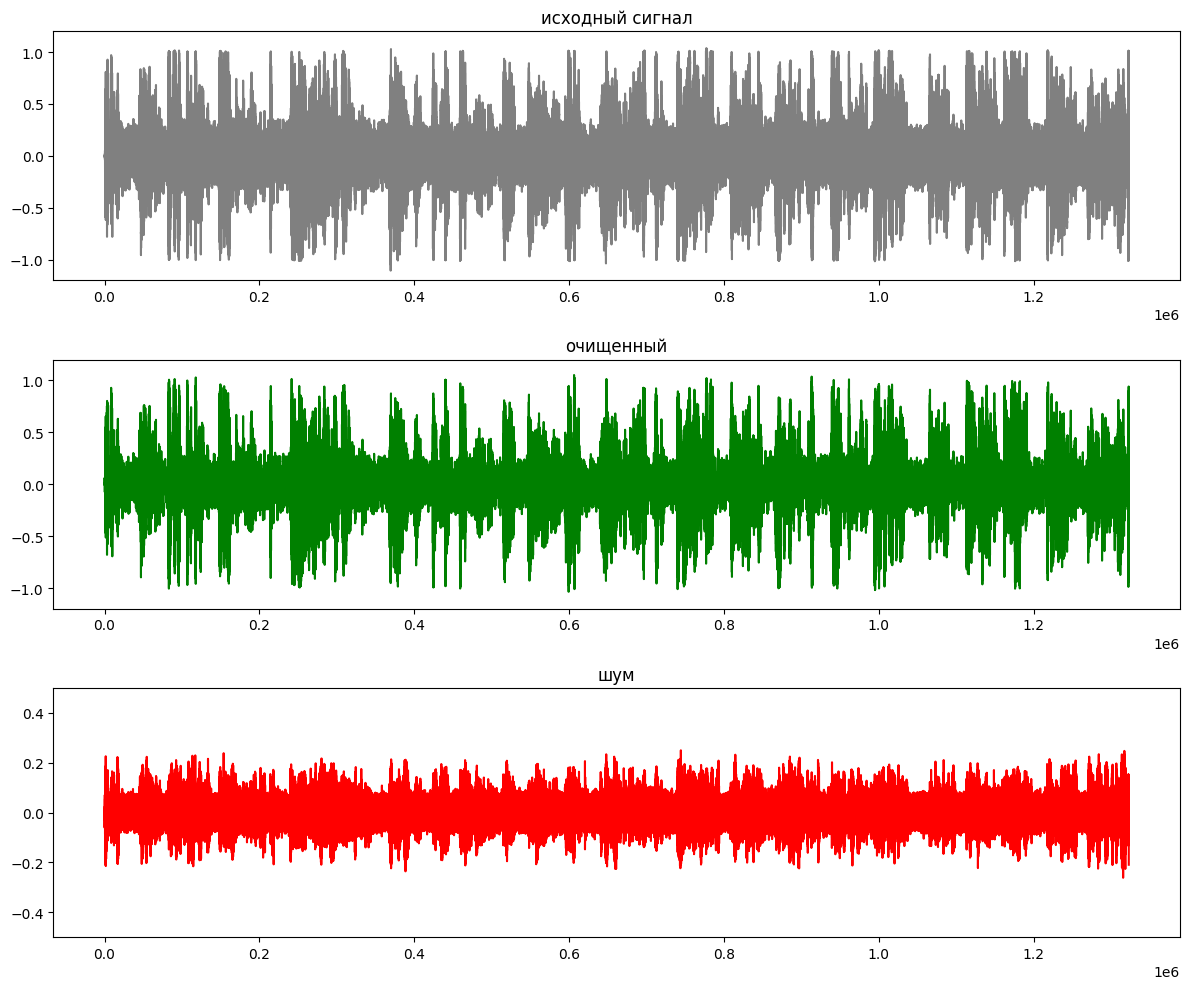

In [13]:
# поиск шумов при помощи разложений
# вейвлет-преобразование для удаления белого шума (наложенный на аудиокнигу)
y, sr = librosa.load('data/book_with_white_noise_1min.wav')

coeff = pywt.wavedec(y, wavelet='db4', mode='per')
sigma = (1 / 0.6745) * np.median(np.abs(coeff[-1]) - np.median(coeff[-1]))
threshold = sigma * np.sqrt(2 * np.log(len(y)))

coeff[1:] = [pywt.threshold(i, value=threshold, mode='soft') for i in coeff[1:]]

y_denoised = pywt.waverec(coeff, wavelet='db4', mode='per')

noise_residue = y - y_denoised

sf.write('data/denoised_book.wav', y_denoised, sr)

plt.figure(figsize=(12, 10))

# исходный шум
plt.subplot(3, 1, 1)
plt.plot(y, color='gray')
plt.title('исходный сигнал')
plt.ylim(-1.2 , 1.2)

# очищенный
plt.subplot(3, 1, 2)
plt.plot(y_denoised, color='green')
plt.title('очищенный')
plt.ylim(-1.2, 1.2)

# только шум
plt.subplot(3, 1, 3)
plt.plot(noise_residue, color='red')
plt.title('шум')
plt.ylim(-0.5, 0.5)

plt.tight_layout()

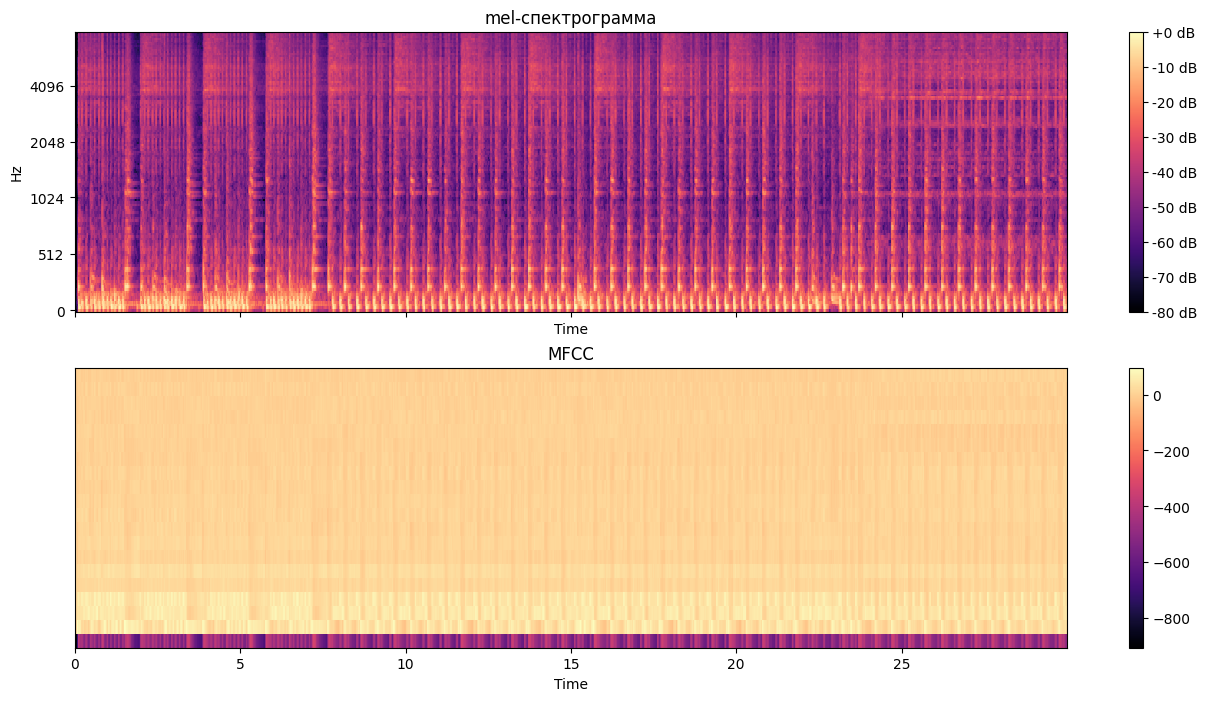

In [ ]:
# mel-спектрограмма - трансформирует частотную ось спектрограммы в шкалу мелов
y, sr = librosa.load('data/baraban-z_uk.wav', duration=30)

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
S_dB = librosa.power_to_db(S, ref=np.max)

# mfccs - мел-кепстральные коэффициенты
mfccs = librosa.feature.mfcc(S=S_dB, n_mfcc=20)

fig, ax = plt.subplots(nrows=2, sharex=True, figsize=(16, 8))

img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000, ax=ax[0])
ax[0].set(title='mel-спектрограмма')
fig.colorbar(img, ax=ax[0], format='%+2.0f dB')

img2 = librosa.display.specshow(mfccs, x_axis='time', ax=ax[1])
ax[1].set(title='MFCC')
fig.colorbar(img2, ax=ax[1])